In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
#import torch
#import torch.nn as nn
#from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import cosine_similarity
from similarities import build_statistical_similarity_graph
from hidden_markov_similarity import build_hmm_graph
import networkx as nx
import matplotlib.pyplot as plt
from plot import save_graph_plot


In [2]:
DATA_PATH = '../../dataset/data_andre.feather'  # Adjust path if needed
print(f"Loading data from {DATA_PATH}...")
# Use pd.read_feather instead of feather.read_table to get a DataFrame directly
df = pd.read_feather(DATA_PATH)

# Filter X number of items for testing
#NUM_ITEMS = 100
#df = df[df['item_id'].isin(df['item_id'].unique()[:NUM_ITEMS])]

Loading data from ../../dataset/data_andre.feather...


In [3]:
# Define constants
DATE_COL = 'date'
TARGET_COL = 'value'  # Assuming 'value' is the target variable (sales at the end of the day)


# Handle DATE_COL (ensure it is a column and not in the index)
if DATE_COL in df.index.names:
    if DATE_COL in df.columns:
        # If it's in both, drop the index version to avoid "cannot insert" error
        df = df.reset_index(drop=True)
    else:
        # If it's only in the index, move it to a column
        df = df.reset_index()

# If DATE_COL is NOT in columns (and wasn't in index), we have a problem, but assuming it exists somewhere.
# Just to be safe, if we still have a complex index, reset it.
if df.index.name == DATE_COL:
     df = df.reset_index(drop=True)
     
# Fallback: simple reset to ensure RangeIndex 0..N
df = df.reset_index(drop=True)

# Ensure date is datetime and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df['item_id'] = df['item_id'].astype(int) # or .astype(str)
df = df.reset_index(drop=True) # Final clean reset

# Prepare target variable
# Using 'value' as the target (sales at the end of the day)
y = df[TARGET_COL]
print(len(y))

# Calandar-based features
# Ensure datetime
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# Base calendar parts
df["day_of_week"]  = df[DATE_COL].dt.dayofweek.astype(int)
df["day_of_month"] = df[DATE_COL].dt.day.astype(int)         
df["moy"]          = df[DATE_COL].dt.month.astype(int)-1      
df["doy"]          = df[DATE_COL].dt.dayofyear.astype(int)-1   
df["is_weekend"] = (
    (df[DATE_COL].dt.dayofweek == 5) |
    (df[DATE_COL].dt.dayofweek == 6)
).astype(int)

m0 = df[DATE_COL].dt.month - 1
df["month_sin"] = np.sin(2*np.pi*m0 / 12)
df["month_cos"] = np.cos(2*np.pi*m0 / 12)

df["doy"] = df[DATE_COL].dt.dayofyear # 1..365/366
doy0 = df["doy"] - 1
P = 366 # safe; or use 365 if you drop leap years
df["doy_sin"] = np.sin(2*np.pi*doy0 / P)
df["doy_cos"] = np.cos(2*np.pi*doy0 / P)

promo_types= [col for col in df.columns if col.startswith("promo_type_")] # Binary columns indicating presence of specific promotion types
promo_values= [col for col in df.columns if col.startswith("promo_value_")] # Numerical columns indicating the value of specific promotion types

calendar_cols = ["day_of_week", "day_of_month", "moy", "doy", "is_weekend"]
calendar_trigonometric_cols = ["month_sin", "month_cos", "doy_sin", "doy_cos"]
categorical_cols = ["cat_label", "sdep_label", "dept_label"]

df = df.sort_values(["item_id", DATE_COL]).reset_index(drop=True)

df

1082371


,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,store_id,day_of_week,day_of_month,moy,doy,is_weekend,month_sin,month_cos,doy_sin,doy_cos
0,2021-01-23,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,6269,5,23,0,23,1,0.0,1.000000,0.368763,0.929523
1,2021-01-24,27,14,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,6269,6,24,0,24,1,0.0,1.000000,0.384665,0.923056
2,2021-01-25,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,6269,0,25,0,25,0,0.0,1.000000,0.400454,0.916317
3,2021-01-26,27,5,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,6269,1,26,0,26,0,0.0,1.000000,0.416125,0.909308
4,2021-01-27,27,8,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0,0.0,0,...,6269,2,27,0,27,0,0.0,1.000000,0.431673,0.902030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082366,2023-02-18,900087600,28,bottled water,pos subd grocery other,pos dept grocery,water/isotonics,0,0.0,0,...,6269,5,18,1,49,1,0.5,0.866025,0.733885,0.679273
1082367,2023-02-19,900087600,46,bottled water,pos subd grocery other,pos dept grocery,water/isotonics,0,0.0,0,...,6269,6,19,1,50,1,0.5,0.866025,0.745438,0.666575
1082368,2023-02-20,900087600,28,bottled water,pos subd grocery other,pos dept grocery,water/isotonics,0,0.0,0,...,6269,0,20,1,51,0,0.5,0.866025,0.756771,0.653680
1082369,2023-02-21,900087600,31,bottled water,pos subd grocery other,pos dept grocery,water/isotonics,0,0.0,0,...,6269,1,21,1,52,0,0.5,0.866025,0.767880,0.640593


In [4]:
graph_list= []


In [5]:
G_pearson, sim_df_pearson, df_pivot_pearson = build_statistical_similarity_graph(
    df,
    date_col="date",
    item_col="item_id",
    target_col="value",
    similarity_method="pearson",
    similarity_threshold=0.8,
    use_absolute_similarity=True
)
graph_list.append((G_pearson, df_pivot_pearson))

Added edge between 18605 and 18607 with pearson similarity: 0.8058
Added edge between 26002 and 26012 with pearson similarity: 0.8558
Added edge between 154813 and 154814 with pearson similarity: 0.8789
Number of nodes in the pearson graph: 1427
Number of edges in the pearson graph: 3


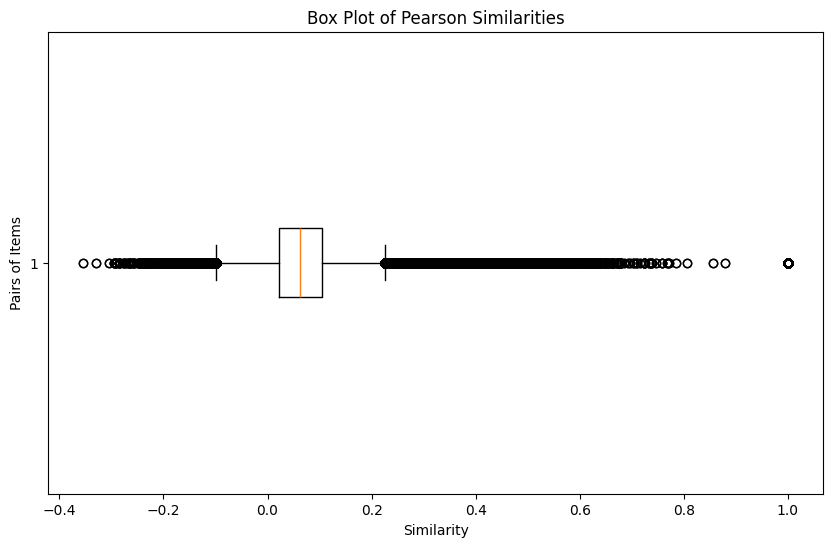

In [6]:
# Box plot of distances
plt.figure(figsize=(10, 6))
plt.boxplot(sim_df_pearson.values.flatten(), vert=False)
plt.title("Box Plot of Pearson Similarities")
plt.xlabel("Similarity")
plt.ylabel("Pairs of Items")
plt.show()

In [7]:
#save_graph_plot(G_pearson, strategy_name="Pearson Correlation", node_categories=dict(zip(df["item_id"], df["cat_label"])))

In [8]:
G_spearman, sim_df_spearman, df_pivot_spearman = build_statistical_similarity_graph(
    df,
    date_col="date",
    item_col="item_id",
    target_col="value",
    similarity_method="spearman",
    similarity_threshold=0.8,
    use_absolute_similarity=True
)
graph_list.append((G_spearman, df_pivot_spearman))

Number of nodes in the spearman graph: 1427
Number of edges in the spearman graph: 0


In [9]:
sim_df_spearman

item_id,27,55,71,116,128,156,176,195,215,219,...,965440,965699,967330,971261,983332,983754,988016,991921,991924,900087600
item_id,,,,,,,,,,,,,,,,,,,,,
27,1.000000,0.039551,0.151629,0.051848,0.180002,0.158091,0.136836,0.138559,0.130933,0.058107,...,0.207100,0.105779,0.091917,0.188858,0.168754,0.072909,0.069083,0.089849,0.054680,-0.003367
55,0.039551,1.000000,0.017041,-0.044339,0.076023,0.020050,0.047327,0.079945,0.138987,0.068451,...,0.104710,0.086735,0.079955,0.064678,-0.016121,-0.019754,0.027360,0.002180,-0.000558,0.067704
71,0.151629,0.017041,1.000000,0.174932,0.193882,0.042533,0.040686,0.009393,0.112757,-0.065770,...,0.021218,-0.154019,0.032450,0.263091,0.053217,-0.042388,-0.041233,0.038943,0.160851,-0.281505
116,0.051848,-0.044339,0.174932,1.000000,0.059903,0.033640,0.083635,0.049680,-0.010706,-0.076307,...,0.016704,-0.115425,0.114325,0.143139,0.004079,-0.012476,0.031359,-0.004293,0.069107,-0.049593
128,0.180002,0.076023,0.193882,0.059903,1.000000,0.037898,0.153333,0.119423,0.092302,0.062955,...,0.069650,0.022594,0.087613,0.230069,0.084925,0.067374,0.088586,0.120431,0.188498,-0.079696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983754,0.072909,-0.019754,-0.042388,-0.012476,0.067374,0.012751,0.061877,0.063029,0.068929,-0.027086,...,0.051602,0.028372,-0.020421,0.077176,0.302156,1.000000,0.063531,0.299568,0.121844,0.035034
988016,0.069083,0.027360,-0.041233,0.031359,0.088586,0.106044,0.081439,0.181393,-0.025423,-0.017434,...,0.031332,0.060727,0.013970,0.069225,0.044335,0.063531,1.000000,0.069403,0.010420,0.054503
991921,0.089849,0.002180,0.038943,-0.004293,0.120431,0.091141,0.067132,0.088492,0.076639,0.024316,...,0.080381,0.015956,0.045767,0.120650,0.330104,0.299568,0.069403,1.000000,0.229916,0.062685


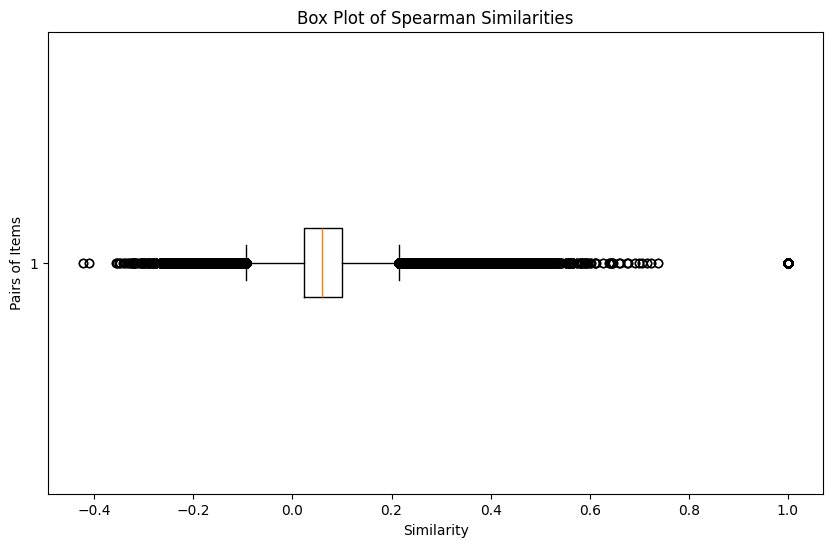

In [10]:
# Box plot of distances
plt.figure(figsize=(10, 6))
plt.boxplot(sim_df_spearman.values.flatten(), vert=False)
plt.title("Box Plot of Spearman Similarities")
plt.xlabel("Similarity")
plt.ylabel("Pairs of Items")
plt.show()

In [11]:
#save_graph_plot(G_spearman, strategy_name="Spearman Correlation", node_categories=dict(zip(df["item_id"], df["cat_label"])))

In [ ]:
G_hmm, sim_df, df_scaled, fit_info = build_hmm_graph(
    df=df,
    date_col="date",
    item_col="item_id",
    target_col="sales",
    aggfunc="sum",
    n_components=3,
    similarity_threshold=0.55,
    use_log1p=True,
    train_end="2024-12-31",   # optional: avoids future leakage
    n_iter=200,
    random_seeds=(0, 1, 2, 3, 4),
    min_covar=1e-4,
    min_obs_per_state=10,
    verbose=False,
    return_fit_info=True,
)


Model is not converging.  Current: 74.68686965908974 is not greater than 74.69230111399166. Delta is -0.005431454901923871
Model is not converging.  Current: 205.13385134663014 is not greater than 205.15552339559108. Delta is -0.021672048960937218
Model is not converging.  Current: -131.45498839914003 is not greater than -131.40747779654953. Delta is -0.04751060259050632
Model is not converging.  Current: -358.13032222089015 is not greater than -358.12967814010625. Delta is -0.0006440807838998808


Added edge between 55 and 1241 with HMM similarity: 0.8381
Added edge between 55 and 26530 with HMM similarity: 0.8765
Added edge between 156 and 2355 with HMM similarity: 0.8069
Added edge between 156 and 34496 with HMM similarity: 0.8328
Added edge between 156 and 65955 with HMM similarity: 0.8889
Added edge between 156 and 112754 with HMM similarity: 0.8001
Added edge between 156 and 157923 with HMM similarity: 0.8872
Added edge between 156 and 502330 with HMM similarity: 0.8811
Added edge between 156 and 557686 with HMM similarity: 0.8387
Added edge between 156 and 905921 with HMM similarity: 0.8217
Added edge between 156 and 917326 with HMM similarity: 0.9294
Added edge between 176 and 2355 with HMM similarity: 0.8159
Added edge between 176 and 20039 with HMM similarity: 0.8060
Added edge between 176 and 34496 with HMM similarity: 0.8272
Added edge between 176 and 46888 with HMM similarity: 0.8923
Added edge between 176 and 100498 with HMM similarity: 0.8044
Added edge between 176